<center>
<img src="https://raw.githubusercontent.com/dvgodoy/PyTorch101_ODSC_Europe2020/master/images/linear_dogs.jpg" width="800">

</center>

# `Домашнее задание 3`

#### Фамилия, имя: Nikolai Popov`

Дата выдачи: <span style="color:red">__5 апреля__</span>.

Дедлайн: <span style="color:red">__16 апреля 23:59__</span>.

Стоимость: __3 балла__ (основная часть заданий) + __2.2 балла__ (бонус) — отнормируем в 10 бальную систему при выставлении в Anytask.

<span style="color:red">__В ноутбуке все клетки должны выполняться без ошибок при последовательном их выполнении.__</span>

## Оценивание и штрафы

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

- my runs:
https://wandb.ai/nickpupkin-nes/DeepL_HA3
https://wandb.ai/nickpupkin-nes/DeepL_HA3_snippet
https://wandb.ai/nickpupkin-nes/ria-news

In [ ]:
!pip install wandb esda > /dev/null 2>&1

In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm
import wandb

import torch.nn.functional as F
from tqdm import tqdm

In [ ]:
import torch
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

# Описание данных

Данные можно [скачать с гугл-диска.](https://drive.google.com/drive/folders/11oCcLplWtp_qm-WuEbfCFP_Mz5K_z3ps?usp=sharing) Если вы делаете задание в колабе, то строчки ниже сами скачают вам данные.



In [ ]:
import gdown

url = "https://drive.google.com/drive/folders/11oCcLplWtp_qm-WuEbfCFP_Mz5K_z3ps?usp=sharing"
gdown.download_folder(url, quiet=True, use_cookies=False)

['/content/news_data/ria_news.tsv',
 '/content/news_data/vk_comments.tsv',
 '/content/news_data/vk_news.tsv']

В таблице `ria_news.tsv`  лежат данные о новостях, вышедших на сайте РИА-НОВОСТИ с 15 марта 2018 года по 31 декабря 2018 года.

- `href` - уникальный идентификатор новости (ссылка на неё)
- `date` - дата публикации новости
- `time` - время публикации новости
- `title` - заголовок новости
- `snippet` - краткое описание новости
- `text` - текст новости
- `category` - категория новости
- `keywords` - ключевые слова (подкатегории новости)
- `shows` - счётчик с числом просмотров новости на сайте (на момент парсинга)

In [ ]:
df_ria = pd.read_csv('news_data/ria_news.tsv', sep='\t')
df_ria = df_ria[~df_ria.tags.isnull()]
print(df_ria.shape)
df_ria.head()

(201708, 9)


,href,date,time,title,snippet,text,category,tags,shows
0,/20181231/1548961410.html,2018-12-31,"31 декабря 2018, 23:52",Нетаньяху не собирается в отставку в случае пр...,Премьер-министр Израиля Биньямин Нетаньяху не ...,"МОСКВА, 31 дек - РИА Новости. Премьер-министр ...",В мире,"Биньямин Нетаньяху, Израиль, В мире",728.0
1,/20181231/1548961364.html,2018-12-31,"31 декабря 2018, 23:19",Макрон в новогоднем обращении затронул тему ре...,"Результат реформ не может быть мгновенным, зая...","ПАРИЖ, 31 дек – РИА Новости. Результат реформ ...",В мире,"Эммануэль Макрон, Франция, В мире",3086.0
2,/20181231/1548961337.html,2018-12-31,"31 декабря 2018, 23:12",Аарон Рэмзи проведет переговоры с пятью топ-кл...,"Полузащитник лондонского ""Арсенала"" Аарон Рэмз...","МОСКВА, 31 дек - РИА Новости. Полузащитник лон...",NaN,ФК Арсенал (Лондон),183.0
3,/20181231/1548961304.html,2018-12-31,"31 декабря 2018, 23:09",Гол Азмуна принес сборной Ирана победу над кат...,Футболисты сборной Ирана одержали победу над к...,"МОСКВА, 31 дек - РИА Новости. Футболисты сборн...",NaN,"Сердар Азмун, Сборная Ирана по футболу",78.0
4,/20181231/1548961265.html,2018-12-31,"31 декабря 2018, 23:07",Пятая ракетка мира дель Потро пропустит Открыт...,Аргентинский теннисист Хуан Мартин дель Потро ...,"МОСКВА, 31 дек - РИА Новости. Аргентинский тен...",NaN,Теннис,79.0


Многие новостные агенства поддерживают странички в социальных сетях. Они постят туда самые сочные сюжеты. В таблице `vk_news.tsv` лежат данные о новостях, которые РИА запостили ВКонтакте в период времени с  `2017-09-29 01:28:55` по `2019-02-01 23:13:17`.

- `id` - уникальный идентификатор поста
- `href` - ссылка на сайт (если она была указана в посте)
- `datetime` - дата и время публикации новости
- `title` - заголовок новости
- `text` - текст новости в социальной сети
- `likes` - число лайков под постом
- `comments` - число комментариев под постом

In [ ]:
df_vk = pd.read_csv('news_data/vk_news.tsv', sep='\t')
df_vk['snippet'] = df_vk['text']
df_vk.drop('text', axis=1, inplace=True)
print(df_vk.shape)
df_vk.head()

(19928, 7)


,id,href,datetime,title,likes,comments,snippet
0,24006362,/20190201/1550280358.html,2019-02-01 23:13:17,"В ДНР заявили о задержании диверсантов, причас...",15,28,NaN
1,24006240,/20190201/1550268781.html,2019-02-01 22:38:41,"Житель Урала ""заминировал"" ТЦ из-за снятия со...",32,42,NaN
2,24006100,/20190201/1550282212.html,2019-02-01 21:58:52,"В Черном море нашли ""потерянный флот Гитлера""",84,23,NaN
3,24005972,/20190202/1550283179.html,2019-02-01 21:27:06,В США освободили задержанную российскую актрис...,58,35,NaN
4,24005764,/20190201/1550262848.html,2019-02-01 20:55:54,Толкнувший Скабееву депутат Рады заявил о гроз...,45,145,NaN


В таблице `vk_comments.tsv` лежат комментарии к новостям.

- `id` - уникальный идентификатор комментария
- `post_id` - идентификатор новости, под которой был оставлен комментарий
- `datetime` - дата и время, когда был оставлен комментарий
- `text` - текст комментария
- `likes` - число лайков под комментарием

In [ ]:
df_comments = pd.read_csv('news_data/vk_comments.tsv', sep='\t')
df_comments = df_comments[~df_comments.text.isnull()]
print(df_comments.shape)
df_comments.head()

<ipython-input-8-9f937a17e540>:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_comments = pd.read_csv('news_data/vk_comments.tsv', sep='\t')


(2612629, 5)


,id,post_id,datetime,text,likes
0,24006366.0,24006362.0,2019-02-01 23:14:14,ЧВК Вагнера?,5.0
1,24006370.0,24006362.0,2019-02-01 23:15:23,"[id4710641|Евгений], выздоравливай.",3.0
2,24006371.0,24006362.0,2019-02-01 23:16:21,"[id442655034|Андрей], искренне желаю этого все...",4.0
3,24006374.0,24006362.0,2019-02-01 23:16:38,Опять про Украину новости?,1.0
4,24006375.0,24006362.0,2019-02-01 23:16:40,Че такое ДНР?,2.0


# А что надо сделать то?

В тетрадке вам предстоит сделать следующие шаги:

1. Вы обучите нейросеть предсказывать категорию новости
2. Вы построите предсказания для тех новостей, где мы ничего не знаем о категории
3. Вы используете уже обученный для сентимент-анализа классификатор из библиотеки `hugging face` чтобы предсказать эмоциональную окраску каждого комментария
4. Вы проведёте аналитику по новостям, а именно построите топы из самых позитивных и негативных категорий и новостей

Для первого шага вам будет дан бэйзлайн. Если вы его прогоните, у вас получится базовая модель, которая даст некоторое качество решения задачи. Вам надо будет выяснить, насколько это качество оказалось хорошим, а затем внести в код некоторые улучшения.



## Часть 1: категоризация новостей (1.2 + 2 бонусных балла)

Каждой новости в соотвествие поставлены ключевые слова. Будем считать, что эти ключевые слова — тематики новости. Нужно научиться предсказывать тематики по тексту новости. Готовые тематики у нас есть только по новостям с сайта. Они за 2018 год. По новостям из ВКонтакте у нас тематик нет. Мы собираемся их предсказать.

Новости, опубликованные ВКонтакте, отличаются от новостей с сайта тем, что у них есть только титул и короткое описание. Странно будет обучать нейросеть на длинных текстах, а потом использовать её на коротких описаниях. Мы не будем так делать. Мы попробуем обучить базовый вариант нейронной сети только на заголовках новостей. Все, кто захочет получить бонусные баллы, смогут попробовать добавить в нейросеть сниппеты (так назыают короткие описания новостей).

## 1.1 Подготовка таргета

Поработаем с таргетом. Мы будем предсказывать переменную `tags`. Давайте выясним сколько уникальных тегов существует.

In [ ]:
from collections import Counter

# удалим все лишние пробелы и сделаем lowercase
df_ria['tags'] = (
    df_ria.tags.
    apply(lambda w: ','.join([item.strip() for item in  w.lower().split(',')]))
)

tags = ','.join(list(df_ria.tags.values))
tags_cnt = Counter(tags.split(','))

print(len(tags_cnt))
tags_cnt.most_common()[-20:]

13344


[('блог анны завершинской об автоспорте - блоги', 1),
 ('министерство транспорта рб', 1),
 ('министерство здравоохранения грузии', 1),
 ('палех', 1),
 ('юрий посохов (хореограф)', 1),
 ('мария александрова', 1),
 ('том бенсон', 1),
 ('абдул каюм кочай', 1),
 ('нуман куртулмуш', 1),
 ('mipim', 1),
 ('владимир попов', 1),
 ('брюно женезио', 1),
 ('роберт фицо', 1),
 ('сергей пашинский', 1),
 ('валерия гонтарева', 1),
 ('нововоронеж', 1),
 ('императорское православное палестинское общество', 1),
 ('event_poslanie_prezidenta_rf_federalnomu_sobraniju', 1),
 ('фхтр', 1),
 ('игорь честин', 1)]

Всего в выборке есть порядка 13 000 тэгов. Многие встречаются всего по разу. Давайте оставим в выборке только те тэги, которые встречаются более 30 раз.

In [ ]:
target_tags = {tag for tag,cnt in tags_cnt.most_common() if cnt > 30}
len(target_tags)

1583

Закодируем теги для OHE.

In [ ]:
tag2idx = dict(zip(target_tags, range(len(target_tags))))
idx2tag = {jtem: item for item,jtem in tag2idx.items()}

Почистим таргет от лишних тэгов.

In [ ]:
df_ria['target_tags'] = (
    df_ria.tags.
    apply(lambda w: [tag2idx.get(item) for item in  w.split(',') if item in target_tags])
)

df_ria = df_ria[df_ria.target_tags.apply(len) > 0]
df_ria.shape

(201437, 10)

In [ ]:
df_ria.target_tags.values[:3]

array([list([337, 1201, 92]), list([1293, 1427, 92]), list([1020])],
      dtype=object)

## 1.2 Подготовка текстов

Теперь займёмся предобработкой текстов. Приведём все слова к маленькому регистру и выбросим мусорные символы. В качестве токенов будем рассматривать отдельные слова.

Напомню, что мы пока что решили работать только с названиями статей. Поэтому вся предобработка применяется исключительно к ним. **Спойлер:** предобработку для сниппетов вы сделаете сами в первом же задании.

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import nltk.data
print(nltk.data.path)

['/root/nltk_data', '/usr/nltk_data', '/usr/share/nltk_data', '/usr/lib/nltk_data', '/usr/share/nltk_data', '/usr/local/share/nltk_data', '/usr/lib/nltk_data', '/usr/local/lib/nltk_data']


In [ ]:
import re
from nltk.tokenize import word_tokenize

def normalise_text(text):
    text = text.lower()

    # сурово регулярками выкидываем мусорные символы
    text = re.sub('[^а-яa-z0-9 ]', '', text)
    return text.strip()

df_ria['title_clean'] = df_ria.title.apply(normalise_text)

word_cnt = Counter(word_tokenize(' '.join(df_ria.title_clean.values)))
len(word_cnt)

112178

In [ ]:
word_cnt.most_common()[:10]

[('в', 127323),
 ('на', 44386),
 ('с', 26150),
 ('и', 21771),
 ('о', 19948),
 ('по', 17014),
 ('россии', 13494),
 ('не', 13483),
 ('сша', 9942),
 ('за', 9881)]

Давайте почистим словарь от стоп-слов и подготовим его к использованию внутри датасета. Мы будем с помощью словаря заменять слова на индексы. Добавим в словарь несколько специальных токенов для неизвестных слов и паддингов.

In [ ]:
from nltk.corpus import stopwords

stops_ru = set(stopwords.words('russian'))
len(stops_ru)

151

In [ ]:
vocabulary = {
    "#PAD#": 0, "#UNK#": 1
}

k = 2
for word, _ in word_cnt.most_common():
    if word not in stops_ru:
        vocabulary[word] = k
        k += 1

In [ ]:
len(vocabulary)

112030

Завернём код для создания словаря в функцию.

In [ ]:
def create_vocab(text, stops_ru=stops_ru):

    word_cnt = Counter(word_tokenize(text))
    vocabulary = {
        "#PAD#": 0, "#UNK#": 1
    }

    k = 2
    for word, _ in word_cnt.most_common():
        if word not in stops_ru:
            vocabulary[word] = k
            k += 1
    return vocabulary

__[0.2 балла] Задание 1:__

- Cделайте аналогичную предобработку титулов из таблички `df_vk`. Запишите получившийся результат в столбец `title_clean` по аналогии с таблицей `df_ria`.
- Сделайте для обеих таблиц предобработку колонок со сниппетами `snippet` и запишите получившийся результат в столбец `snippet_clean`. Все пропуски заполните токеном `"#UNKN"`.

In [ ]:
# your code here
# ヽ(♡‿♡)ノ

df_vk['title_clean'] = df_vk.title.apply(normalise_text)

df_ria['snippet_clean'] = df_ria['snippet'].apply(normalise_text)
df_vk['snippet'] = df_vk['snippet'].fillna('#UNK#')
df_vk['snippet_clean'] = df_vk['snippet'].apply(normalise_text)

df_vk['snippet_clean'].head()

,snippet_clean
0,unk
1,unk
2,unk
3,unk
4,unk


## 1.3 Поставка данных

Пересечение сайта и ВК по опубликованным новостям довольно маленькое. Мы обучаем модель на данных с сайта. Предсказания мы будем строить на данных из ВК. У этих данных разная природа. В ВК описание статей и заголовки короче. Модель может хорошо показать себя на данных с новостного сайта, но сильно просесть в качестве на данных из ВК.

Давайте сохраним пересечение в отдельную табличку, чтобы на нём можно было понять, насколько сильно деградирует модель.

In [ ]:
ria_hrefs = set(df_ria.href.values)
vk_hrefs = set(df_vk.href.values)
test_hrefs = (vk_hrefs & ria_hrefs)

print('Размер отложенной выборки:', len(test_hrefs))

df = df_ria[~df_ria.href.isin(test_hrefs)]

Размер отложенной выборки: 1128


По странному совпадению (я правда не знаю почему) пересечение лежит в декабре. Мы будем его использовать как тестовую выборку.

In [ ]:
df_ria[df_ria.href.isin(test_hrefs)].date.min(), df_ria[df_ria.href.isin(test_hrefs)].date.max()

('2018-12-06', '2018-12-31')

Предположим, что мы делим выборку на обучающую и тестовую случайно. За один и тот же промежуток времени может выйти довольно большое число новостей с одинаковым заголовком. Давайте представим себе, что в тесте и трэйне есть много статей про одно и то же событие. Модель научилась на обучающей выборке хорошо его тегировать. Остальные события модель тегирует намного хуже. Метрики на тестовой выборке высокие. В следующем месяце СМИ перестают освещать это событие, в потоке новостей совершенно другие новости. Качество модели резко проседает.

Чтобы не напороться на завышенные метрики, обычно выборку дробят на обучающую и тестовую по времени. Тогда статьи из теста будут имитировать поток новых новостей, освещающих новые события.

In [ ]:
df.date.min(), df.date.max()

('2018-03-15', '2018-12-31')

__[0.2 балла] Задание 2:__ Разбейте выборку на обучающую, валидационную и тестовую. В тест возьмите весь декабрь. В валидацию октябрь и ноябрь.

In [ ]:
# your code here
# ♡ (´｡• ω •｡`)

df_ria['date'] = pd.to_datetime(df_ria['date'])

# train , validation and test samples
df_train = df_ria[(df_ria['date'] < '2018-10-01')]  # Train (before Octobet)
df_val = df_ria[(df_ria['date'] >= '2018-10-01') & (df_ria['date'] < '2018-12-01')]  # October - November
df_test = df_ria[df_ria['date'] >= '2018-12-01'] # December

Сформируем отложенную выборку (пересечение ВКонтакте и РИА).

In [ ]:
df_oob = df_vk[df_vk.href.isin(test_hrefs)][['href', 'title_clean']]

df_ria_oob = df_ria[df_ria.href.isin(test_hrefs)][['href', 'target_tags']]
df_oob = df_oob.set_index('href').join(df_ria_oob.set_index('href')).reset_index()
df_oob.head()

,href,title_clean,target_tags
0,/20181231/1548960744.html,митрополит рязанский раскритиковал иронию судьбы,[904]
1,/20181231/1548958617.html,на украине позавидовали стене на границе с крымом,"[390, 92]"
2,/20181231/1548957394.html,в госдуме предложили отказаться от газа в жилы...,"[997, 997, 1230, 54, 1384]"
3,/20181231/1548954909.html,названы лучшие средства от похмелья,[904]
4,/20181231/1548957120.html,новогоднее поздравление порошенко разозлило по...,"[390, 92]"


Напишем датасет для поставки данных в нейросеть.


In [ ]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

# class NewsDataset(Dataset):

#     def __init__(self, target, title, vocab, vocab_size, max_title_len, max_classes, snippet=None, max_snippet_len=None):

#        self.vocab = {word: idx  for word,idx in vocab.items() if idx < vocab_size}
#        self.max_classes = max_classes
#        self.y=self.target_ohe(target)
#        self.X_title = self.create_text(title, max_title_len)

#     def target_ohe(self, target):
#         y = torch.zeros((len(target), self.max_classes))
#         for i, t in enumerate(target):
#             y[[i]*len(t), t] = 1.0
#         return y

#     def create_text(self, texts, max_len):
#         result = [ ]
#         for sent in texts:
#             # {#PAD: 0, #UNKN: 1}
#             sent_tokenize = [self.vocab.get(item, 1) for item in word_tokenize(sent)]

#             # приводим все тексты к max_len
#             if len(sent_tokenize) >= max_len:
#                 sent_tokenize = sent_tokenize[:max_len]
#             else:
#                 sent_tokenize += [0] * (max_len - len(sent_tokenize))
#             result.append(sent_tokenize)
#         return torch.tensor(result, dtype=torch.int)

#     def __len__(self):
#         return len(self.X_title)

#     def __getitem__(self, idx):
#         return (self.X_title[idx, :], self.y[idx])


__[0.2 балла] Задание 3:__ Сейчас датасет умеет работать только с полем `title_clean`. Давайте сделаем этот датасет более многофукнциональным и добавим в него возможность добавить в обработку данных сниппет.

1. Внутри датасета `snippet` надо обработать точно также как и `title`.
2. Если `snippet=None`, датасет должен вернуть два объекта: `X_title, y`. В обратном случае датасет должен вернуть три объекта.

**Важно:** Весь код ниже работает сейчас без сниппета. Он не должен развалиться от того, что сниппет в нём нигде не указан.

In [ ]:
wandb.init(project='DeepL_HA3')

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nickpupkin (nickpupkin-nes) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ▬▬ι═══════  bzzzzzzzzzz
# will the code be with you

# Внесите в код датасета выше свои правки

class NewsDataset(Dataset):
    def __init__(self, target, title, vocab, vocab_size, max_title_len, max_classes, snippet=None, max_snippet_len=None):
        # Filter vocabulary: only keep words whose index is less than vocab_size
        self.vocab = {w: idx for w, idx in vocab.items() if idx < vocab_size}
        self.max_classes = max_classes
        # One-hot encode the target labels
        self.y = self._encode_targets(target)
        # Process title texts into fixed-length sequences of token indices
        self.X_title = self._create_sequence(title, max_title_len)
        # Process snippet texts similarly if provided; otherwise, store None
        if snippet is not None:
            self.X_snippet = self._create_sequence(snippet, max_snippet_len)
        else:
            self.X_snippet = None

    def _encode_targets(self, target):
        """
        Convert list of target label lists to a one-hot encoded tensor.
        Each sample may have multiple labels.
        """
        encoded = torch.zeros((len(target), self.max_classes))
        for i, labels in enumerate(target):
            # Set 1.0 for each target label belonging to sample i
            for label in labels:
                encoded[i, label] = 1.0
        return encoded

    def _create_sequence(self, texts, max_len):
        """
        Tokenize each text, convert tokens to indices, and pad/truncate to max_len.
        Unknown tokens default to index 1.
        """
        sequences = []
        for text in texts:
            # Tokenize the text and map tokens using the vocabulary
            tokens = [self.vocab.get(token, 1) for token in word_tokenize(text)]
            # Truncate if tokens exceed max_len; otherwise, pad with 0 (the PAD index)
            if len(tokens) >= max_len:
                tokens = tokens[:max_len]
            else:
                tokens.extend([0] * (max_len - len(tokens)))
            sequences.append(tokens)
        return torch.tensor(sequences, dtype=torch.int)

    def __len__(self):
        return len(self.X_title)

    def __getitem__(self, idx):
        # If snippet data exists, return (title, snippet, target); otherwise, return (title, target)
        if self.X_snippet is None:
            return self.X_title[idx, :], self.y[idx]
        else:
            return self.X_title[idx, :], self.X_snippet[idx, :], self.y[idx]

Объявим датасеты, оставим в словаре 30 000 самых частотных слов. Будем смотреть на титулы максимальной длины 20.

In [ ]:
CLASSES_NUM = len(idx2tag)
VOCAB_SIZE = 10000
MAX_TITLE_LEN = 20
MAX_SNIPPET_LEN = 50

# словарь создаем по всей выборке
vocabulary = create_vocab(' '.join(df_ria.title_clean.values))

# # объявляем датасеты (without snippets)
train_dataset = NewsDataset(df_train.target_tags.values, df_train.title_clean.values, vocabulary, VOCAB_SIZE, MAX_TITLE_LEN, CLASSES_NUM )
val_dataset = NewsDataset(df_val.target_tags.values, df_val.title_clean.values, vocabulary, VOCAB_SIZE, MAX_TITLE_LEN, CLASSES_NUM )
test_dataset = NewsDataset(df_test.target_tags.values, df_test.title_clean.values, vocabulary, VOCAB_SIZE, MAX_TITLE_LEN, CLASSES_NUM )

# объявляем датасеты (with snippets)
train_dataset_s = NewsDataset(df_train.target_tags.values, df_train.title_clean.values, vocabulary, VOCAB_SIZE, MAX_TITLE_LEN, CLASSES_NUM, df_train.snippet_clean.values, MAX_SNIPPET_LEN)
val_dataset_s = NewsDataset(df_val.target_tags.values, df_val.title_clean.values, vocabulary, VOCAB_SIZE, MAX_TITLE_LEN, CLASSES_NUM, df_train.snippet_clean.values, MAX_SNIPPET_LEN )
test_dataset_s = NewsDataset(df_test.target_tags.values, df_test.title_clean.values, vocabulary, VOCAB_SIZE, MAX_TITLE_LEN, CLASSES_NUM, df_train.snippet_clean.values, MAX_SNIPPET_LEN )

In [ ]:
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=64, num_workers=4)
val_dataloader = DataLoader(val_dataset, shuffle=False, batch_size=4096, num_workers=4)

# with snippets
train_dataloader_s = DataLoader(train_dataset_s, shuffle=True, batch_size=64, num_workers=4)
val_dataloader_s = DataLoader(val_dataset_s, shuffle=False, batch_size=4096, num_workers=4)

## 1.4 Архитектуры

Соберём базовую архитектуру для обучения.

In [ ]:
from torch import nn
import torch.nn.functional as F

class SimpleClassifier(nn.Module):

    def __init__(self, vocab_size, embedding_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.fc = nn.Linear(embedding_dim, output_dim)

    def forward(self, title):
        embedded = self.embedding(title)
        embedded = embedded.mean(dim=1)
        return self.fc(embedded)

Соберём в `pytorch_lightning` модуль для обучения нейронки.

In [ ]:
!pip3 install pytorch_lightning esda > /dev/null 2>&1

In [ ]:
import pytorch_lightning as pl

class TrainLightningModule(pl.LightningModule):
    def __init__(self, model, learning_rate, criterion):
        super().__init__()
        self.model = model
        self.criterion = criterion
        self.learning_rate = learning_rate

    def forward(self, title):
        result = self.model(title)
        return result

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def training_step(self, train_batch, batch_idx):
        title, target = train_batch
        logits = self.model(title)
        loss = self.criterion(logits, target)
        self.log(
            "train_loss", loss, prog_bar=True
        )
        return loss

    def validation_step(self, val_batch, batch_idx):
        title, target = val_batch
        logits = self.model(title)
        loss = self.criterion(logits, target)
        self.log(
            "val_loss", loss, prog_bar=True
        )
        return loss

Обучим модель.

In [ ]:
EMBEDDING_DIM = 300
EPOCHS = 5
LR = 1e-3

model_baseline = SimpleClassifier(VOCAB_SIZE, EMBEDDING_DIM, CLASSES_NUM)
criterion = torch.nn.CrossEntropyLoss()

train_module =TrainLightningModule(model_baseline, LR, criterion)

trainer = pl.Trainer(accelerator="gpu", max_epochs=EPOCHS)
trainer.fit(train_module, train_dataloader, val_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type             | Params |

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


__[0.2 балла] Задание 4:__  Модель выше работает только с титулом.

- Залоггируйте её обучение на [WandB](https://wandb.ai/).
- Соберите архитектуру, которая будет принимать на вход не только титул, но ещё и сниппет. В этой архитектуре должно происходить следующее:

1. Общий слой `nn.Embedding` применяется к сниппету и титулу параллельно.
2. Происходит усреднее по текстам.
3. Вектора конкатятся в один длины 600
4. Линейный слой делает классификацию

Обучите эту модель. Сравните траектории обучения на WandB. Прикрепите ссылку на дашборд либо скришот к тетрадке.

Даталоадеры придётся объявить заново с учётом сниппетов. Правда ли, что она бьёт на валидационной выборке модель, обученную только на титулах статей?

In [ ]:
wandb.init(project='DeepL_HA3_snippet')

In [ ]:
from torch import nn
import torch.nn.functional as F

class SimpleClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.fc = nn.Linear(embedding_dim * 2, output_dim)

    def forward(self, input_title, input_snippet):
        if input_snippet is not None:
            title_embeds = self.embedding(input_title).mean(dim=1)
            snippet_embeds = self.embedding(input_snippet).mean(dim=1)
            combined = torch.cat([title_embeds, snippet_embeds], dim=1)
        else:
            combined = self.embedding(input_title).mean(dim=1)
        return self.fc(combined)

class TrainLightningModule(pl.LightningModule):
    def __init__(self, model, learning_rate, criterion):
        super().__init__()
        self.model = model
        self.criterion = criterion
        self.learning_rate = learning_rate

    def forward(self, title, snippet):
        return self.model(title, snippet)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def training_step(self, batch, batch_idx):
        # Unpack batch: snippet data is included
        title_batch, snippet_batch, labels = batch
        logits = self.model(title_batch, snippet_batch)
        loss = self.criterion(logits, labels)
        self.log("train_loss", loss, prog_bar=True)
        wandb.log({"train_loss": loss})
        return loss

    def validation_step(self, batch, batch_idx):
        # Unpack validation batch (title, snippet, labels)
        title_batch, snippet_batch, labels = batch
        logits = self.model(title_batch, snippet_batch)
        loss = self.criterion(logits, labels)
        self.log("val_loss", loss, prog_bar=True)
        wandb.log({"val_loss": loss})
        return loss

In [ ]:
EMBEDDING_DIM = 300
EPOCHS = 5
LR = 1e-3

model_baseline = SimpleClassifier(VOCAB_SIZE, EMBEDDING_DIM, CLASSES_NUM)
criterion = torch.nn.CrossEntropyLoss()

train_module =TrainLightningModule(model_baseline, LR, criterion)

trainer = pl.Trainer(accelerator="gpu", max_epochs=EPOCHS, logger=pl.loggers.WandbLogger())
trainer.fit(train_module, train_dataloader_s, val_dataloader_s)

INFO:pytorch_lightning.utilities.rank_zero:You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type             | Params | Mode 
-------------------------------------------------------
0 | model     | SimpleClassifier | 4.0 M  | train
1 | criterion | CrossEn

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


Ну, не знаю - у меня val_loss только подрос. Странно))

## 1.5 Инференс и оценка качества моделей

Для каждой новости нам надо предсказывать несколько тэгов. То есть в нашем случае настоящее значение таргета это множество из тэгов $y_i = [tag1, tag2, tag3]$. Прогноз модели также множество из тэгов $\hat y_i = [tag1, tag4]$.

Будем считать метрики качества следующим образом (под $|A|$ имеется в виду мощность множества, то есть число элементов в нём):

$$
Precision = \frac{1}{n} \sum_{i = 1}^n \frac{|y_i \cap \hat{y}_i|}{|\hat{y}_i|}
$$

$$
Recall = \frac{1}{n} \sum_{i = 1}^n \frac{|y_i \cap \hat{y}_i|}{|y_i|}
$$

Также можно считать аналог Accuracy, но это не самая удачная идея, так как у нас в выборке огромное число нулей и эта метрика при любом разумном пороге для принятия решения будет очень высокой.

$$
Exact Match = \frac{1}{n} \cdot \frac{1}{k} \sum_{i = 1}^n \sum_{k=1}^K [y_{ij} = \hat{y}_{ij}]
$$

In [ ]:
def precision(target, y_pred):
    num = ((y_pred == 1) & (target == 1)).sum(dim=1)
    denum = (y_pred == 1).sum(dim=1)
    return (num/(denum + 1e-5)).mean().item()

def recall(target, y_pred):
    num = ((y_pred == 1) & (target == 1)).sum(dim=1)
    denum = (target == 1).sum(dim=1)
    return (num/(denum + 1e-5)).mean().item()

def exact_match(target, y_pred):
    return (1.*(y_pred == target)).mean().item()

Построим прогноз на тестовой выборке.

In [ ]:
test_dataloader_s = DataLoader(test_dataset_s, shuffle=False, batch_size=test_dataset_s.__len__())

for title, snippet, target in test_dataloader_s:
    logit = model_baseline(title, snippet) # , snippet was added - otherwise didn't work
    pred_prob = F.softmax(logit, dim=1)

assert pred_prob.shape[0] == test_dataset.__len__()

Теперь выбирая различное значение порога, мы можем получать разные предсказания. Если взять очень большое значение порога, то метрики сильно просядут, так как во многих документах никакого прогноза не будет построено вообще.

In [ ]:
TRESHOLD = 0.01
y_pred = 1*(pred_prob > TRESHOLD)

print('Exact Match:', exact_match(target, y_pred))
print('Precision:', precision(target, y_pred))
print('Recall:', recall(target, y_pred))

Exact Match: 0.9940195083618164
Precision: 0.15820789337158203
Recall: 0.5120348930358887


In [ ]:
TRESHOLD = 0.05
y_pred = 1*(pred_prob > TRESHOLD)
print('Exact Match:', exact_match(target, y_pred))
print('Precision:', precision(target, y_pred))
print('Recall:', recall(target, y_pred))

Exact Match: 0.9973953366279602
Precision: 0.26063916087150574
Recall: 0.30390477180480957


In [ ]:
TRESHOLD = 0.9
y_pred = 1*(pred_prob > TRESHOLD)

print('Exact Match:', exact_match(target, y_pred))
print('Precision:', precision(target, y_pred))
print('Recall:', recall(target, y_pred))

Exact Match: 0.9983164668083191
Precision: 0.0017367454711347818
Recall: 0.0009810293558984995


Дальше мы будем строить довольно много прогнозов. Давайте напишем код для их строительства в виде функции. Обратите внимание, что на модели со снипетом она упадёт. Когда вы доберётесь до строительства прогнозов, функцию придётся немного модернизировать.

In [ ]:
def get_predict(model, dataset):
    dataloader = DataLoader(dataset, shuffle=False, batch_size=dataset.__len__())

    for title, target in dataloader:
        logit = model(title)
        pred_prob = F.softmax(logit, dim=1)

    assert pred_prob.shape[0] == dataset.__len__()
    return pred_prob, target

__[0.2 балла] Задание 5:__ Какая метрика для нас в этой задаче важнее? Точность или полнота? Почему?

__ваш ответ:__

- Напишите функцию, которая будет подбирать оптимальное значение порога, оптимизирующее выбранную вами метрику.
- Подберите значение порога на валидационной выборке.
- Сравните модель со сниппетами и без сниппетов, используя выбранную вами метрику при оптимальном значении порога на тестовой выборке.
- Какая из них оказалась лучше?

In this task, precision is more important. In news categorization, each wrong assignment (a false positive) could cause users to receive irrelevant or inappropriate news content. High precision ensures that the news articles assigned to a specific category truly belong there. Prioritizing precision minimizes erroneous predictions, even if it means some relevant articles might be missed (resulting in lower recall).

In [ ]:
def find_best_threshold(model, dataset, metric='precision', batch_size=64):
    """
    Finds the optimal threshold for the given metric for models/datasets that do not include snippet data.
    A dummy snippet (zeros) is passed to the model.
    """
    from torch.utils.data import DataLoader
    import torch.nn.functional as F
    from tqdm import tqdm

    loader = DataLoader(dataset, shuffle=False, batch_size=batch_size)
    best_score = -float('inf')
    best_threshold = 0.5
    candidate_thresholds = torch.linspace(0, 0.9, steps=20)

    for thr in tqdm(candidate_thresholds, desc="Optimizing threshold"):
        all_predictions = []
        all_targets = []

        with torch.no_grad():
            for titles, targets in loader:
                # Create a dummy snippet tensor (same shape as titles)
                dummy_snippet = torch.zeros_like(titles)
                logits = model(titles, dummy_snippet)
                probabilities = F.softmax(logits, dim=1)
                preds = (probabilities > thr).float()
                all_predictions.append(preds)
                all_targets.append(targets)

        all_predictions = torch.cat(all_predictions, dim=0)
        all_targets = torch.cat(all_targets, dim=0)

        if metric == 'precision':
            current_score = precision(all_targets, all_predictions)
        elif metric == 'recall':
            current_score = recall(all_targets, all_predictions)
        elif metric == 'exact_match':
            current_score = exact_match(all_targets, all_predictions)
        else:
            raise ValueError("Metric '{}' not recognized.".format(metric))

        if current_score > best_score:
            best_score = current_score
            best_threshold = thr.item()

        del all_predictions, all_targets
        torch.cuda.empty_cache()

    return best_threshold


def find_best_threshold_snippet(model, dataset, metric='precision', batch_size=64):
    """
    Finds the optimal threshold for the given metric for models/datasets that include snippet data.
    """
    from torch.utils.data import DataLoader
    import torch.nn.functional as F
    from tqdm import tqdm

    loader = DataLoader(dataset, shuffle=False, batch_size=batch_size)
    best_score = -float('inf')
    best_threshold = 0.5
    candidate_thresholds = torch.linspace(0, 0.9, steps=20)

    for thr in tqdm(candidate_thresholds, desc="Optimizing threshold (Snippet)"):
        all_predictions = []
        all_targets = []

        with torch.no_grad():
            for titles, snippets, targets in loader:
                logits = model(titles, snippets)
                probabilities = F.softmax(logits, dim=1)
                preds = (probabilities > thr).float()
                all_predictions.append(preds)
                all_targets.append(targets)

        all_predictions = torch.cat(all_predictions, dim=0)
        all_targets = torch.cat(all_targets, dim=0)

        if metric == 'precision':
            current_score = precision(all_targets, all_predictions)
        elif metric == 'recall':
            current_score = recall(all_targets, all_predictions)
        elif metric == 'exact_match':
            current_score = exact_match(all_targets, all_predictions)
        else:
            raise ValueError("Metric '{}' not recognized.".format(metric))

        if current_score > best_score:
            best_score = current_score
            best_threshold = thr.item()

        del all_predictions, all_targets
        torch.cuda.empty_cache()

    return best_threshold


In [ ]:
# For the version without snippet data:
print("Optimal Thresholds (No Snippet):")
opt_thr_precision = find_best_threshold(model_baseline, val_dataset, metric='precision', batch_size=64)
opt_thr_recall    = find_best_threshold(model_baseline, val_dataset, metric='recall', batch_size=64)
opt_thr_exact     = find_best_threshold(model_baseline, val_dataset, metric='exact_match', batch_size=64)

print("Precision optimal threshold:", opt_thr_precision)
print("Recall optimal threshold:", opt_thr_recall)
print("Exact Match optimal threshold:", opt_thr_exact)

# For the version with snippet data:
print("Optimal Thresholds (With Snippet):")
opt_thr_snip_precision = find_best_threshold_snippet(model_baseline, val_dataset_s, metric='precision', batch_size=64)
opt_thr_snip_recall    = find_best_threshold_snippet(model_baseline, val_dataset_s, metric='recall', batch_size=64)
opt_thr_snip_exact     = find_best_threshold_snippet(model_baseline, val_dataset_s, metric='exact_match', batch_size=64)

print("Precision optimal threshold (snippet):", opt_thr_snip_precision)
print("Recall optimal threshold (snippet):", opt_thr_snip_recall)
print("Exact Match optimal threshold (snippet):", opt_thr_snip_exact)

Optimal Thresholds (No Snippet):


Optimizing threshold: 100%|██████████| 20/20 [00:33<00:00,  1.69s/it]


Precision optimal threshold: 0.09473683685064316
Recall optimal threshold: 0.0
Exact Match optimal threshold: 0.2368420958518982
Optimal Thresholds (With Snippet):


Optimizing threshold (Snippet): 100%|██████████| 20/20 [00:40<00:00,  2.03s/it]

Precision optimal threshold (snippet): 0.09473683685064316
Recall optimal threshold (snippet): 0.0
Exact Match optimal threshold (snippet): 0.5210525989532471


Now let's compare the model by precision, given the optimal threshold

In [ ]:
def evaluate_precision(model, dataset, optimal_threshold, batch_size=64, with_snippet=False):
    """
    Evaluates the precision on the given dataset using the optimal threshold.

    If with_snippet is True but the dataset yields only (title, target) pairs,
    a dummy snippet (zero tensor) is created.
    """
    from torch.utils.data import DataLoader
    import torch.nn.functional as F

    loader = DataLoader(dataset, shuffle=False, batch_size=batch_size)
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            # Check the number of items in the batch
            if with_snippet:
                if len(batch) == 3:
                    title_batch, snippet_batch, target_batch = batch
                elif len(batch) == 2:
                    # Create a dummy snippet tensor since only title and target are provided
                    title_batch, target_batch = batch
                    snippet_batch = torch.zeros_like(title_batch)
                else:
                    raise ValueError("Unexpected number of elements in batch")
                logits = model(title_batch, snippet_batch)
            else:
                # For non-snippet mode, we still need to pass a dummy snippet to satisfy the model
                title_batch, target_batch = batch
                dummy_snippet = torch.zeros_like(title_batch)
                logits = model(title_batch, dummy_snippet)

            probabilities = F.softmax(logits, dim=1)
            binary_preds = (probabilities > optimal_threshold).float()
            all_preds.append(binary_preds)
            all_labels.append(target_batch)

    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    return precision(all_labels, all_preds)



In [ ]:
# Evaluate model without snippet
test_precision_no_snip = evaluate_precision(model_baseline, test_dataset, opt_thr_precision, batch_size=64, with_snippet=False)
print("Test precision (no snippet):", test_precision_no_snip)

# Evaluate model with snippet
test_precision_snip = evaluate_precision(model_baseline, test_dataset_s, opt_thr_snip_precision, batch_size=64, with_snippet=True)
print("Test precision (with snippet):", test_precision_snip)

Test precision (no snippet): 0.25665995478630066
Test precision (with snippet): 0.27791330218315125


Ну, как и ожидалось- модель со снипеттами лучше - она все же больше информации использует. Но опять же - без оптимального threshold- результат был другим.

__[0.2 балла] Задание 6:__  Постройте прогнозы для отложенной выборки, которая представляет из себя пересечение сайта РИА-новостей и ВКонтакте. Проседает ли на ней качество модели? Насколько сильно?

In [ ]:
df_oob.head()

,href,title_clean,target_tags
0,/20181231/1548960744.html,митрополит рязанский раскритиковал иронию судьбы,[904]
1,/20181231/1548958617.html,на украине позавидовали стене на границе с крымом,"[390, 92]"
2,/20181231/1548957394.html,в госдуме предложили отказаться от газа в жилы...,"[997, 997, 1230, 54, 1384]"
3,/20181231/1548954909.html,названы лучшие средства от похмелья,[904]
4,/20181231/1548957120.html,новогоднее поздравление порошенко разозлило по...,"[390, 92]"


In [ ]:
df_oob_dataset = NewsDataset(
    target=df_oob.target_tags.values,  # Target labels from df_oob
    title=df_oob.title_clean.values,    # Cleaned titles from df_oob
    snippet=None,                       # No snippet data provided
    vocab=vocabulary,                   # Vocabulary mapping words to indices
    vocab_size=VOCAB_SIZE,              # Maximum vocabulary size
    max_title_len=MAX_TITLE_LEN,        # Maximum title token length
    max_classes=CLASSES_NUM             # Total number of classes
)

Modify get_tredict to work with no smippets as well

In [ ]:
def get_predict(model, dataset, batch_size=64):
    """
    Gets prediction probabilities and true targets from the model.
    If the dataset returns only (title, target), a dummy snippet is created.
    """
    from torch.utils.data import DataLoader
    import torch.nn.functional as F

    loader = DataLoader(dataset, shuffle=False, batch_size=batch_size)
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            # Check if the batch returns two or three items
            if len(batch) == 2:
                # Unpack batch (titles, targets) and create dummy snippet
                titles, targets = batch
                dummy_snippet = torch.zeros_like(titles)
                logits = model(titles, dummy_snippet)
            elif len(batch) == 3:
                # Unpack batch (titles, snippets, targets)
                titles, snippets, targets = batch
                logits = model(titles, snippets)
            else:
                raise ValueError("Unexpected batch length: expected 2 or 3 elements.")

            probs = F.softmax(logits, dim=1)
            all_probs.append(probs)
            all_targets.append(targets)

    all_probs = torch.cat(all_probs, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    return all_probs, all_targets

In [ ]:
# Get prediction probabilities and true labels for the out-of-bound (OOB) dataset
oob_prob, oob_target = get_predict(model_baseline, df_oob_dataset)

# Convert probabilities to binary predictions using the optimal threshold (best_thresh)
y_oob = (oob_prob > opt_thr_snip_precision).int()

print('Postponed sample:')
print('Exact Match:', exact_match(oob_target, y_oob))
print('Precision:', precision(oob_target, y_oob))
print('Recall:', recall(oob_target, y_oob))

Postponed sample:
Exact Match: 0.9977614283561707
Precision: 0.16341465711593628
Recall: 0.09852125495672226


Просело сильно - чуть ли не в два раза.

## 1.6 Бонусное задание

Давайте модернизируем наши архитектуры настолько, насколько это возможно.

__[0.5 балла]__ Попробуйте собрать более большую архитектуру. Например, сразу после слоя эмбеддингов вы можете попробовать добавить свёрточные слои (`Conv1D` свёртки). Поиграйте с оптимизатором и тп.

Опишите результаты своих экспериментов ниже. Расскажите, что конкретно вы делали и удалось ли вам улучшить качество модели. Все траектории обучения залоггируйте на WandB.   

__Ваш лог экспериментов:__

-
-
-

Well, I hope, it works. Problem with data link. I tested it before, but I added some chages... hope) ALso. when I finally undesrtood how to wandb... of course))

In [ ]:
wandb.init(
    project="ria-news",
    name="hybrid-conv-gru-run-1",
    config={
        "model": "HybridConvGRUClassifier",
        "embedding_dim": EMBEDDING_DIM,
        "hidden_dim": 128,
        "optimizer": "AdamW",
        "lr": 1e-3,
        "epochs": EPOCHS
    }
)

In [ ]:
class HybridConvGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.conv_title = nn.Conv1d(embedding_dim, hidden_dim, kernel_size=3, padding=1)
        self.conv_snippet = nn.Conv1d(embedding_dim, hidden_dim, kernel_size=3, padding=1)

        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True, bidirectional=True)

        self.attn = nn.Linear(hidden_dim * 2, 1)
        self.norm = nn.LayerNorm(hidden_dim * 4)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 4, output_dim)

    def encode(self, x, conv):
        x = self.embedding(x).permute(0, 2, 1)
        x = conv(x).permute(0, 2, 1)
        x, _ = self.gru(x)
        weights = F.softmax(self.attn(x), dim=1)
        x = (x * weights).sum(dim=1)
        return x

    def forward(self, title, snippet):
        title_vec = self.encode(title, self.conv_title)
        snippet_vec = self.encode(snippet, self.conv_snippet)
        combined = torch.cat([title_vec, snippet_vec], dim=1)
        combined = self.norm(combined)
        combined = self.dropout(combined)
        return self.fc(combined)

class TrainModule(pl.LightningModule):
    def __init__(self, model, learning_rate, criterion):
        super().__init__()
        self.model = model
        self.criterion = criterion
        self.learning_rate = learning_rate

    def forward(self, title, snippet):
        return self.model(title, snippet)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.learning_rate)

    def training_step(self, batch, batch_idx):
        title, snippet, target = batch
        logits = self(title, snippet)
        loss = self.criterion(logits, target)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        title, snippet, target = batch
        logits = self(title, snippet)
        loss = self.criterion(logits, target)
        self.log("val_loss", loss, prog_bar=True)
        return loss


In [ ]:
# Instantiate model
model = HybridConvGRUClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=128,
    output_dim=CLASSES_NUM
)

# Criterion and training wrapper
criterion = torch.nn.CrossEntropyLoss()
train_module = TrainModule(model, learning_rate=1e-3, criterion=criterion)

# WandB logger
wandb_logger = WandbLogger(project="ria-news", name="hybrid-conv-gru")

# Trainer
trainer = pl.Trainer(
    accelerator="gpu",
    max_epochs=EPOCHS,
    logger=wandb_logger
)

# Train
trainer.fit(train_module, train_dataloader_s, val_dataloader_s)

# Run model predictions on validation and test sets
val_outputs, val_labels = get_predict(model, val_dataset_snip)
test_outputs, test_labels = get_predict(model, test_dataset_snip)

# Determine optimal classification threshold based on validation recall
optimal_threshold, max_recall = find_best_threshold(val_outputs, val_labels, recall)

print(f"Optimal threshold for recall optimization: {optimal_threshold:.3f} | Recall: {max_recall:.4f}")

# Apply threshold to test predictions
test_preds = (test_outputs > optimal_threshold).int()

# Evaluate model on the test set
print("\nTest Set Performance:")
print(f"Recall:        {recall(test_labels, test_preds):.4f}")
print(f"Precision:     {precision(test_labels, test_preds):.4f}")
print(f"Exact Match:   {exact_match(test_labels, test_preds):.4f}")

In [ ]:
# Model: DualBranchConvGRUWithGating
class DualBranchConvGRUWithGating(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.conv_title = nn.Conv1d(embedding_dim, hidden_dim, kernel_size=3, padding=1)
        self.conv_snippet = nn.Conv1d(embedding_dim, hidden_dim, kernel_size=3, padding=1)
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(hidden_dim * 2, 1)

        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 4, hidden_dim * 2),
            nn.Sigmoid()
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def encode_branch(self, x, conv):
        x = self.embedding(x).permute(0, 2, 1)
        x = conv(x).permute(0, 2, 1)
        x, _ = self.gru(x)
        weights = F.softmax(self.attn(x), dim=1)
        return (x * weights).sum(dim=1)

    def forward(self, title, snippet):
        title_vec = self.encode_branch(title, self.conv_title)
        snippet_vec = self.encode_branch(snippet, self.conv_snippet)
        combined = torch.cat([title_vec, snippet_vec], dim=1)
        gated = self.gate(combined)
        fused = gated * title_vec + (1 - gated) * snippet_vec
        return self.fc(self.dropout(fused))

# PyTorch Lightning module
class TrainModule(pl.LightningModule):
    def __init__(self, model, learning_rate, criterion):
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate
        self.criterion = criterion

    def forward(self, title, snippet):
        return self.model(title, snippet)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.learning_rate)

    def training_step(self, batch, batch_idx):
        title, snippet, target = batch
        logits = self(title, snippet)
        loss = self.criterion(logits, target)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        title, snippet, target = batch
        logits = self(title, snippet)
        loss = self.criterion(logits, target)
        self.log("val_loss", loss, prog_bar=True)
        return loss

# WandB setup and training
wandb.login()

wandb_logger = WandbLogger(
    project="ria-news",
    name="dual-branch-gated",
    config={
        "model": "DualBranchConvGRUWithGating",
        "embedding_dim": EMBEDDING_DIM,
        "hidden_dim": 128,
        "optimizer": "AdamW",
        "lr": 1e-3,
        "epochs": EPOCHS
    }
)

model = DualBranchConvGRUWithGating(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=128,
    output_dim=CLASSES_NUM
)

train_module = TrainModule(model, learning_rate=1e-3, criterion=nn.CrossEntropyLoss())

trainer = pl.Trainer(
    accelerator="gpu",
    max_epochs=EPOCHS,
    logger=wandb_logger
)

trainer.fit(train_module, train_dataloader_s, val_dataloader_s)

# Predict on validation and test sets
val_outputs, val_labels = get_predict(model, val_dataset_snip)
test_outputs, test_labels = get_predict(model, test_dataset_snip)

# Optimize threshold on validation set
optimal_threshold, max_recall = find_best_threshold(val_outputs, val_labels, recall)
print(f"Optimal threshold for recall optimization: {optimal_threshold:.3f} | Recall: {max_recall:.4f}")

# Apply threshold to test predictions
test_preds = (test_outputs > optimal_threshold).int()

# Evaluate
print("\nTest Set Performance:")
print(f"Recall:        {recall(test_labels, test_preds):.4f}")
print(f"Precision:     {precision(test_labels, test_preds):.4f}")
print(f"Exact Match:   {exact_match(test_labels, test_preds):.4f}")


In [ ]:
# Model: Residual CNN
class ResidualCNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.conv1 = nn.Conv1d(embedding_dim, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1)
        self.conv3 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1)
        self.proj = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def encode_branch(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        out1 = F.relu(self.conv1(x))
        out2 = F.relu(self.conv2(out1) + out1)
        out3 = F.relu(self.conv3(out2) + out2)
        pooled = F.adaptive_max_pool1d(out3, 1).squeeze(-1)
        return pooled

    def forward(self, title, snippet):
        t_vec = self.encode_branch(title)
        s_vec = self.encode_branch(snippet)
        combined = torch.cat([t_vec, s_vec], dim=1)
        combined = self.dropout(self.proj(combined))
        return self.fc(combined)

# Lightning training module
class TrainModule(pl.LightningModule):
    def __init__(self, model, learning_rate, criterion):
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate
        self.criterion = criterion

    def forward(self, title, snippet):
        return self.model(title, snippet)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.learning_rate)

    def training_step(self, batch, batch_idx):
        title, snippet, target = batch
        logits = self(title, snippet)
        loss = self.criterion(logits, target)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        title, snippet, target = batch
        logits = self(title, snippet)
        loss = self.criterion(logits, target)
        self.log("val_loss", loss, prog_bar=True)
        return loss

# WandB init
wandb.login()

# Instantiate model
model = ResidualCNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=128,
    output_dim=CLASSES_NUM
)

# Criterion and training wrapper
criterion = torch.nn.CrossEntropyLoss()
train_module = TrainModule(model, learning_rate=1e-3, criterion=criterion)

# WandB logger
wandb_logger = WandbLogger(project="ria-news", name="residual-cnn")

# Trainer
trainer = pl.Trainer(
    accelerator="gpu",
    max_epochs=EPOCHS,
    logger=wandb_logger
)

# Train
trainer.fit(train_module, train_dataloader_s, val_dataloader_s)

# Predict on validation and test sets
val_outputs, val_labels = get_predict(model, val_dataset_snip)
test_outputs, test_labels = get_predict(model, test_dataset_snip)

# Optimize threshold on validation set
optimal_threshold, max_recall = find_best_threshold(val_outputs, val_labels, recall)
print(f"Optimal threshold for recall optimization: {optimal_threshold:.3f} | Recall: {max_recall:.4f}")

# Apply threshold to test predictions
test_preds = (test_outputs > optimal_threshold).int()

# Evaluate
print("\nTest Set Performance:")
print(f"Recall:        {recall(test_labels, test_preds):.4f}")
print(f"Precision:     {precision(test_labels, test_preds):.4f}")
print(f"Exact Match:   {exact_match(test_labels, test_preds):.4f}")

__[0.5]__ Скачайте с сайта [Rusvectores](https://rusvectores.org/ru/models/) любые новостные word2vec эмбединги. Возьмите из модели эмбеддинги для всех слов, которые встречаются вв вашем словаре и добавьте их в модель первым слоем. Заморозьте этот слой и не обновляйте в нём веса. Если у вас в словаре есть слово, но его нет среди предобученных эмбеддингов, замените его на токен `#UNKN`.

__Ваш лог экспериментов:__

-
-
-

__[1 балл]__ Зафайнтьюньте трансформер для решения задачи с помощью библиотеки `hugging face`. Выбор предобученной модели кратко обоснуйте.

__Ваш лог экспериментов:__

-
-
-

In [ ]:
# your code here
# ٩(ˊ〇ˋ*)و


Сравните все обученные модели между собой на тестовой выборке.

In [ ]:
# your code here
# (⌐■_■)

## Часть 2: предсказание категорий (0.3 балла)

Возьмите датасет `df_vk` и для всех новостей из него предскажите категории с помощью лучшей, получившейся у вас модели.

In [ ]:
df_vk['target_tags'] = [[0]]*df_vk.shape[0]

simple_classifier_dataset = NewsDataset(
    target=[[0]] * df_vk.shape[0],
    title=df_vk.title_clean.values,
    snippet=df_vk.snippet_clean.values,
    vocab=vocabulary,
    vocab_size=VOCAB_SIZE,
    max_title_len=MAX_TITLE_LEN,
    max_snippet_len=MAX_SNIPPET_LEN,
    max_classes=CLASSES_NUM
)

simple_classifier_pred_prob, _ = get_predict(model_baseline, simple_classifier_dataset)

In [ ]:
THRESHOLD = 0.01
simple_classifier_pred_tags = (simple_classifier_pred_prob > THRESHOLD).int()

На всякий случай сохраните табличку с получившимися у вас предсказаниями. Мало ли, вы не доделаете последнее задание, а потом захотите вернуться к нему. Не прогонять же обучение нейросети и инференс по второму кругу...

In [ ]:
df_vk["Target_Tags"] = simple_classifier_pred_tags.tolist()

## Часть 3: сентимент-классификатор (0.5 балла)

В этой части тетрадки нам предстоит прогнать все комментарии из ВК через сентимент-классификатор. Мы будем делать это с помощью библиотеки HuggingFace. В ней есть удобная [функциональность pipline,](https://huggingface.co/docs/transformers/pipeline_tutorial) чтобы прогонять на своих данных уже обученные модели. 🤗🤗🤗

In [ ]:
df_comments.head()

,id,post_id,datetime,text,likes
0,24006366.0,24006362.0,2019-02-01 23:14:14,ЧВК Вагнера?,5.0
1,24006370.0,24006362.0,2019-02-01 23:15:23,"[id4710641|Евгений], выздоравливай.",3.0
2,24006371.0,24006362.0,2019-02-01 23:16:21,"[id442655034|Андрей], искренне желаю этого все...",4.0
3,24006374.0,24006362.0,2019-02-01 23:16:38,Опять про Украину новости?,1.0
4,24006375.0,24006362.0,2019-02-01 23:16:40,Че такое ДНР?,2.0


Для классификации комментариев на позитивные, негативные и нейтральные будем использовать [модель, о которой можно почитать по ссылке](https://huggingface.co/seara/rubert-tiny2-russian-sentiment)

Ответьте на следующие вопросы:

1. Как зовут автора модели?
2. Как выглядит архитектура модели? Насколько модель большая?
3. На каких данных обучена модель? Адекватно ли использовать её для классификации комментариев ВК?


1)
The model was created by someone (or a team) using the name “seara.”

2)
It uses a small, transformer-based architecture similar to BERT but designed specifically for Russian. It’s a “tiny” version, which means it has fewer layers and parameters compared to the full-sized BERT models. This makes it faster and lighter, though it might not be as powerful as bigger models.

3)
The model was fine-tuned on Russian text data for sentiment analysis. This usually includes text from social media, reviews, and other real-world sources. Because of that, it should work pretty well for classifying the sentiment of VK comments into positive, negative, or neutral.

Установим библиотеку. 🤗🤗🤗

In [ ]:
!pip3 install transformers esda > /dev/null 2>&1

Разберитесь как можно прогнать модель на корпусе комментариев и сделайте это. Да, с помощью pipeline можно запустить довольно сложные модели, обученные другими людьми в пару строчек. При объявлении модели не забудьте положить её на нужный `device` 🤗🤗🤗

In [ ]:
# Import the necessary libraries
from transformers import pipeline
!pip install datasets  esda > /dev/null 2>&1 # Ensure the datasets library is installed
from datasets import Dataset
import torch

# Choose the computation device: GPU (index 0) if available, otherwise CPU (-1)
device_index = 0 if torch.cuda.is_available() else -1

# Set up the sentiment analysis pipeline with a pre-trained Russian sentiment model.
# The model is loaded on the chosen device.
sentiment_classifier = pipeline(
    task="sentiment-analysis",
    model="seara/rubert-tiny2-russian-sentiment",
    device=device_index
)

# Convert the 'text' column from the DataFrame into a Hugging Face Dataset format.
comments_dataset = Dataset.from_pandas(df_comments[["text"]])

# Execute the sentiment analysis on the comment texts.
# The texts are processed in batches for efficiency,
# and any text longer than 32 tokens is truncated.
predictions = sentiment_classifier(
    comments_dataset["text"],
    batch_size=16224, # should work faster - less iterations needed
    truncation=True,
    max_length=32 # yes, I was forced to reduce it to minimum - just took forever
)

# Extract the results: assign the sentiment labels and their confidence scores back to the DataFrame.
df_comments["sentiment"] = [entry["label"] for entry in predictions]
df_comments["sentiment_score"] = [entry["score"] for entry in predictions]

Device set to use cuda:0


Цикл для сентимент-анализа комментариев может работать довольно долго. Я крайне рекомендую вам переодически сохранять к себе на компьютер промежуточные результаты. Итоговый результат я рекомендую записать отдельным столбиком в таблицу с комментариями, а затем сохранить полученные результаты. 🤗🤗🤗

## Часть 4: аналитика (1 балл + 0.2 бонусных)

Мы с вами огромные молодцы. Мы обучили модель для категоризации новостей, построили с её помощью прогнозы. Мы проскорили комментарии на их сентимент-окрас. Теперь давайте проанализируем новости. Описывайте полученные результаты таким образом, чтобы не получить уголовку на 5 лет за дискредитацию чего-нибудь или оскорбление чувств кого-нибудь 💜

__[0.2 балла]__ Какая доля комментариев позитивная? Какая доля комментариев негативная? Выведите 10 самых позитивных комментариев.

Выведите 10 самых негативных комментариев, поугарайте с них. Удалите их вывод из тетрадки. Никто не должен их видеть, это должно остаться только между нами. Поззитивные не удаляйте. Они пусть останутся.

In [ ]:
# Calculate the number of comments in the dataset
num_comments = len(df_comments)

# Compute the fraction of comments with positive and negative sentiment
positive_fraction = (df_comments["sentiment"] == "positive").sum() / num_comments
negative_fraction = (df_comments["sentiment"] == "negative").sum() / num_comments

# Display the percentages in a formatted output
print(f"Percentage of Positive Comments: {positive_fraction:.2%}")
print(f"Percentage of Negative Comments: {negative_fraction:.2%}")

# --- Top 10 positive comments (keep them visible!) ---
top_positive_entries = (
    df_comments[df_comments["sentiment"] == "positive"]
    .sort_values(by="sentiment_score", ascending=False)
    .head(10)[["text", "sentiment_score"]]
)

print("Top 10 Positive Comments:")
print(top_positive_entries)

# --- Top 10 negative comments (shhh, hidden from output) ---
top_negative_entries = (
    df_comments[df_comments["sentiment"] == "negative"]
    .sort_values(by="sentiment_score", ascending=False)
    .head(10)[["text", "sentiment_score"]]
)

Percentage of Positive Comments: 7.30%
Percentage of Negative Comments: 19.37%
Top 10 Positive Comments:
                                                      text  sentiment_score
508965                    Отлично, молодец!Поздравляю!✨💫🌟💥         0.996725
1424111  Отлично! Просто отлично! Молодцы! Поздравляю о...         0.996674
2434524                        отлично,молодцы!!!👍 респект         0.996605
2128990                          Отлично! \nПоздравляем!!!         0.996536
2146325                                     Отлично,я рад.         0.996462
243929                                     Отлично,молодцы         0.996461
1342337                     Отлично,люблю ездить в Эмираты         0.996450
296711                       Отлично! Здоровья всем желаю!         0.996444
423821                      Я очень счастлива! Поздравляю!         0.996431
1737559                           Отлично, просто отлично!         0.996418


__[0.2 балла]__ Для каждой новости из датасета посчитайте количество негативных и позитивных комментариев под ней. Сохраните эти количества в виде новых колонок.

In [ ]:
# Ensure the IDs are of integer type to safely merge the datasets
df_comments["post_id"] = df_comments["post_id"].astype(int)
df_vk["id"] = df_vk["id"].astype(int)

# Filter only positive and negative comments, then count them by post
sentiment_summary = (
    df_comments[df_comments["sentiment"].isin(["positive", "negative"])]
    .groupby(["post_id", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

# Add missing columns if one of the sentiments was not present
for sentiment_type in ["positive", "negative"]:
    if sentiment_type not in sentiment_summary.columns:
        sentiment_summary[sentiment_type] = 0

# Rename columns for clarity
sentiment_summary = sentiment_summary.rename(columns={
    "positive": "positive_comment_count",
    "negative": "negative_comment_count"
})

# Merge the sentiment counts into the original news/posts DataFrame
df_vk = df_vk.merge(
    sentiment_summary,
    how="left",
    left_on="id",
    right_on="post_id"
)

# Preview the result
df_vk.head()

,id,href,datetime,title,likes,comments,snippet,title_clean,snippet_clean,target_tags,Target_Tags,negative_comment_count,positive_comment_count
0,24006362,/20190201/1550280358.html,2019-02-01 23:13:17,"В ДНР заявили о задержании диверсантов, причас...",15,28,#UNK#,в днр заявили о задержании диверсантов причаст...,unk,[0],"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",10.0,1.0
1,24006240,/20190201/1550268781.html,2019-02-01 22:38:41,"Житель Урала ""заминировал"" ТЦ из-за снятия со...",32,42,#UNK#,житель урала заминировал тц изза снятия сотов...,unk,[0],"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",11.0,3.0
2,24006100,/20190201/1550282212.html,2019-02-01 21:58:52,"В Черном море нашли ""потерянный флот Гитлера""",84,23,#UNK#,в черном море нашли потерянный флот гитлера,unk,[0],"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",4.0,3.0
3,24005972,/20190202/1550283179.html,2019-02-01 21:27:06,В США освободили задержанную российскую актрис...,58,35,#UNK#,в сша освободили задержанную российскую актрис...,unk,[0],"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.0,2.0
4,24005764,/20190201/1550262848.html,2019-02-01 20:55:54,Толкнувший Скабееву депутат Рады заявил о гроз...,45,145,#UNK#,толкнувший скабееву депутат рады заявил о гроз...,unk,[0],"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",33.0,9.0


__[0.2 балл]__ Правда ли, что новости с большим количеством лайков получают больше негативных комментариев? А позитивных? Правда ли, что чем больше лайков, тем под новостью больше комментариев?

Постройте визуализацию, которая могла бы это проиллюстрировать.

Correlation between likes and positive comments: 0.576
Correlation between likes and negative comments: 0.102
Correlation between likes and total comments: 0.267


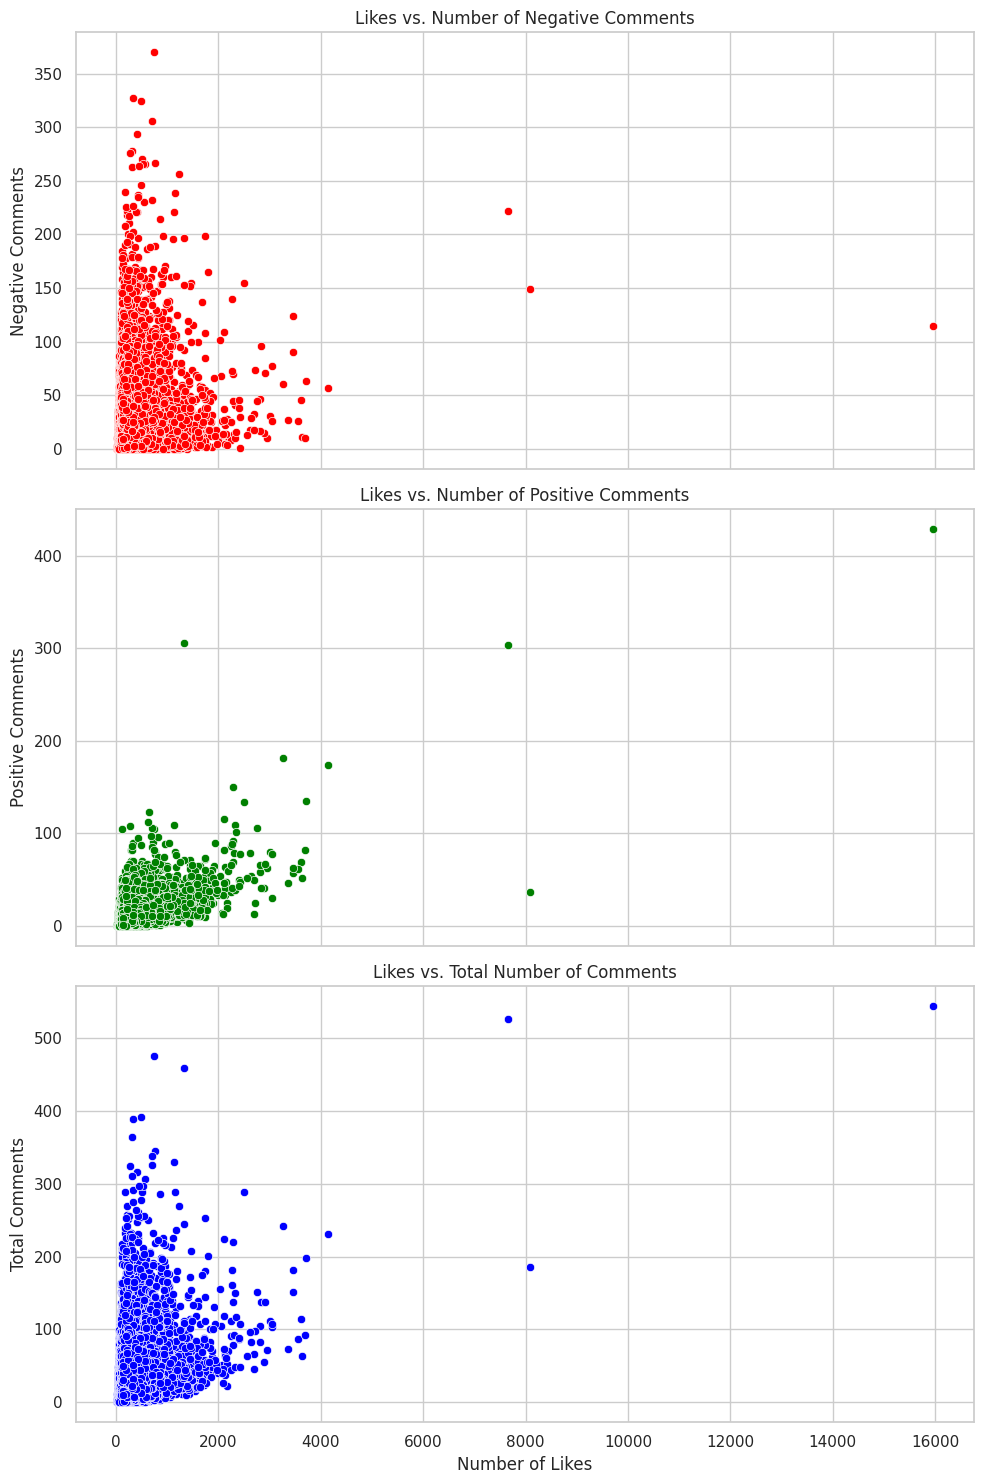

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fill missing values with 0 if needed
df_vk["positive_comment_count"] = df_vk["positive_comment_count"].fillna(0)
df_vk["negative_comment_count"] = df_vk["negative_comment_count"].fillna(0)

# Compute total comments
df_vk["total_comments"] = df_vk["positive_comment_count"] + df_vk["negative_comment_count"]

# --- Correlation Analysis ---
corr_pos = df_vk["likes"].corr(df_vk["positive_comment_count"])
corr_neg = df_vk["likes"].corr(df_vk["negative_comment_count"])
corr_total = df_vk["likes"].corr(df_vk["total_comments"])

print(f"Correlation between likes and positive comments: {corr_pos:.3f}")
print(f"Correlation between likes and negative comments: {corr_neg:.3f}")
print(f"Correlation between likes and total comments: {corr_total:.3f}")

# --- Visualization ---
sns.set(style="whitegrid")
fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

sns.scatterplot(data=df_vk, x="likes", y="negative_comment_count", ax=axs[0], color="red")
axs[0].set_title("Likes vs. Number of Negative Comments")
axs[0].set_ylabel("Negative Comments")

sns.scatterplot(data=df_vk, x="likes", y="positive_comment_count", ax=axs[1], color="green")
axs[1].set_title("Likes vs. Number of Positive Comments")
axs[1].set_ylabel("Positive Comments")

sns.scatterplot(data=df_vk, x="likes", y="total_comments", ax=axs[2], color="blue")
axs[2].set_title("Likes vs. Total Number of Comments")
axs[2].set_xlabel("Number of Likes")
axs[2].set_ylabel("Total Comments")

plt.tight_layout()
plt.show()


I would say that the only really visible correlation- between likes and positive comments)

__[0.2]__  Давайте построим по сентимент-окрасу комментариев топ позитивных новостей.

- Если под новостью оставлено 100 комментариев, из которых 80 позитивные, мы можем быть уверены в том, что новость была хорошо воспринята людьми.
- Если под новостью всего один комментарий и он оказался позитивным, то у нас 100% позитивных комментариев, но это вовсе не означает, что новость была воспринята хорошо.

Получается, что сортировать по доле позитивных комментариев нельзя. Давайте поступим умнее. Доля позитивных комментариев под постом -- это случайная величина. Её довольно часто моделируют с помощью бета-распределения. Если это случайная величина, мы можем построить для неё предиктивный интервал. Пусть $u$ - число позитивных комментариев, а $d$ - нейтральных и негативных.  Пусть

$$
a = 1 + u \qquad b = 1 + d.
$$

Тогда нижняя граница $95\%$ предиктивного интервала для доли будет вычисляться по такой формуле:

$$
\frac{a}{a + b} - 1.65 \cdot \sqrt{\frac{a \cdot b}{(a + b)^2 \cdot (a + b + 1)}}
$$

Если под новостью был всего один комментарий, у такой случайной величины будет высокая дисперсия. Это означаen, что штука, которую мы вычитаем из доли, окажется высокой. Левая граница интервала окажется маленькой и мы не поднимем комментарий в нашем топе наверх. Фактически мы делаем сортировку по квантилю уровня $0.05$ вместо среднего.

От вас требуется вбить эту формулу, сделать сортировку и вывести на экран топ позитивных новостей. Подробнее про то, откуда берётся эта формула можно почитать [в этой книге.](https://disk.yandex.ru/i/Ctd08bTwC9eI3g) Ищите 4 главу, страницу 140.

In [ ]:
# Step 1: Define counts of positive and all other comments
pos_comments = df_vk["positive_comment_count"]
non_pos_comments = df_vk["comments"] - pos_comments  # includes neutral + negative

# Step 2: Compute alpha and beta parameters for the Beta distribution
alpha = 1 + pos_comments
beta = 1 + non_pos_comments

# Step 3: Apply the lower bound formula for 95% predictive interval
confidence_lower_bound = (alpha / (alpha + beta)) - 1.65 * np.sqrt(
    (alpha * beta) / ((alpha + beta) ** 2 * (alpha + beta + 1))
)

# Step 4: Store this "lower bound of confidence" as a new metric
df_vk["positive_score_lower"] = confidence_lower_bound

# Step 5: Sort and display the top 10 most confidently positive news posts
top_confident_news = df_vk.sort_values("positive_score_lower", ascending=False).head(10)

# Step 6: Display key info
top_confident_news[[
    "title",
    "likes",
    "comments",
    "positive_comment_count",
    "negative_comment_count",
    "positive_score_lower"
]]

,title,likes,comments,positive_comment_count,negative_comment_count,positive_score_lower
6651,Сборная России выиграла командный турнир на че...,1387,53,34.0,0.0,0.530298
6620,Россиянки заняли третье место в ските среди юн...,359,14,10.0,0.0,0.502010
12529,"""Ак Барс"" стал трехкратным обладателем Кубка Г...",1292,78,42.0,3.0,0.446092
19213,Фигуристы Тарасова и Морозов победили в соревн...,642,27,16.0,1.0,0.437839
7572,"Россиянин Иван Бессонов победил в конкурсе ""кл...",1882,119,60.0,2.0,0.429443
4968,Сборная России вернулась в Москву после победы...,983,54,29.0,5.0,0.426719
13794,В Финляндии появился отель на лыжах,274,16,10.0,0.0,0.426576
14020,"Миленина выиграла биатлонную гонку на 12,5 км,...",1106,28,16.0,0.0,0.419815
18449,Российская фигуристка Медведева победила на эт...,1092,60,31.0,4.0,0.412243
13930,Вопреки всему: россияне стали вторыми на Парал...,2429,96,47.0,1.0,0.406898


Построили? Срочно пришлите свою любимую позитивную  новость в общий чат!!!

Топ негативных новостей строить не будем. Вокруг итак слишком много негатива 😻😻😻

__[0.2]__ Какие категории новостей оказались самыми позитивными? Придумайте способ найти такие категории и опишите его тут.

__Ответ:__

In [ ]:
# Step 1: Explode the list of tags so each tag becomes its own row
df_tags_exploded = df_vk.explode("target_tags").dropna(subset=["target_tags"])

# Step 2: Group by tag, summing positive and total comments
category_stats = df_tags_exploded.groupby("target_tags").agg({
    "positive_comment_count": "sum",
    "total_comments": "sum"
}).reset_index()

# Step 3: Calculate non-positive comments
category_stats["non_positive"] = category_stats["total_comments"] - category_stats["positive_comment_count"]

# Step 4: Compute Beta confidence interval lower bound
a_cat = 1 + category_stats["positive_comment_count"]
b_cat = 1 + category_stats["non_positive"]

category_stats["positive_score_lower"] = (a_cat / (a_cat + b_cat)) - 1.65 * np.sqrt(
    (a_cat * b_cat) / ((a_cat + b_cat) ** 2 * (a_cat + b_cat + 1))
)

# Step 5: Sort and view the most positively received categories
most_positive_categories = category_stats.sort_values("positive_score_lower", ascending=False)

# Step 6: Show the top 5
most_positive_categories[["target_tags", "positive_comment_count", "total_comments", "positive_score_lower"]].head()


,target_tags,positive_comment_count,total_comments,positive_score_lower
0,0,190649.0,696690.0,0.272769


__[0.2 бонусных]__ Проанализируйте, как температура комментария (вероятность того, что он негативный) зависит от длины трэда (число комментариев под новостью)? Значима ли эта взаимосвязь? Если вам для проверки этого хочется построить линейную регрессию, не сдерживайтесь.

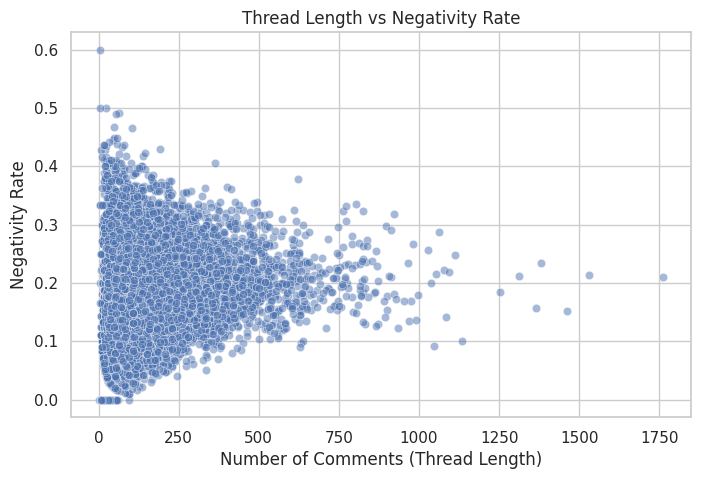

                            OLS Regression Results                            
Dep. Variable:        negativity_rate   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     872.6
Date:                Wed, 16 Apr 2025   Prob (F-statistic):          9.80e-188
Time:                        18:38:59   Log-Likelihood:                 24294.
No. Observations:               19927   AIC:                        -4.858e+04
Df Residuals:                   19925   BIC:                        -4.857e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1569      0.001    204.210      0.0

In [ ]:
import statsmodels.api as sm
# Make sure NaNs are handled
df_vk["negative_comment_count"] = df_vk["negative_comment_count"].fillna(0)
df_vk["comments"] = df_vk["comments"].fillna(0)

# Filter out posts with zero comments (to avoid division by zero)
df_vk_filtered = df_vk[df_vk["comments"] > 0].copy()

# Step 1: Compute the negativity rate ("temperature")
df_vk_filtered["negativity_rate"] = df_vk_filtered["negative_comment_count"] / df_vk_filtered["comments"]

# Step 2: Visual check - plot thread length (comments) vs negativity
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_vk_filtered, x="comments", y="negativity_rate", alpha=0.5)
plt.title("Thread Length vs Negativity Rate")
plt.xlabel("Number of Comments (Thread Length)")
plt.ylabel("Negativity Rate")
plt.show()

# Step 3: Run a simple linear regression
X = sm.add_constant(df_vk_filtered["comments"])  # add intercept
y = df_vk_filtered["negativity_rate"]

model = sm.OLS(y, X).fit()
print(model.summary())

Well, significantly positive, but very litte effect.